# BÀI TẬP LAB 03: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) - AMES HOUSING DATASET

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [23]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Đọc tập dữ liệu train và test từ Kaggle

In [24]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')


# Kiểm tra kích thước dữ liệu (Shape)

In [25]:
print("=== 1. KÍCH THƯỚC DỮ LIỆU ===")
print(f"Kích thước tập Train (Số dòng, Số cột): {train_df.shape}")
print(f"Kích thước tập Test (Số dòng, Số cột):  {test_df.shape}")

=== 1. KÍCH THƯỚC DỮ LIỆU ===
Kích thước tập Train (Số dòng, Số cột): (1460, 81)
Kích thước tập Test (Số dòng, Số cột):  (1459, 80)


# Đọc thông tin tổng quan (Info & Describe)

In [26]:
print("\n=== 2. THÔNG TIN KIỂU DỮ LIỆU (INFO) ===")
print(train_df.info())

print("\n=== 3. THỐNG KÊ MÔ TẢ BIẾN SỐ (DESCRIBE) ===")
print(train_df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].head(10))


=== 2. THÔNG TIN KIỂU DỮ LIỆU (INFO) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQua

# Phân loại 79 thuộc tính (Numerical vs Categorical)

In [27]:
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.drop(['Id', 'SalePrice'])
cat_cols = train_df.select_dtypes(include=['object']).columns

print("\n=== 4. PHÂN LOẠI ĐẶC TRƯNG (FEATURES) ===")
print(f"Số lượng biến định lượng (Numerical): {len(num_cols)}")
print(f"Số lượng biến định tính (Categorical): {len(cat_cols)}")



=== 4. PHÂN LOẠI ĐẶC TRƯNG (FEATURES) ===
Số lượng biến định lượng (Numerical): 36
Số lượng biến định tính (Categorical): 43


# Phân tích biến mục tiêu SalePrice (Kiểm tra Skewness & Log Transform)


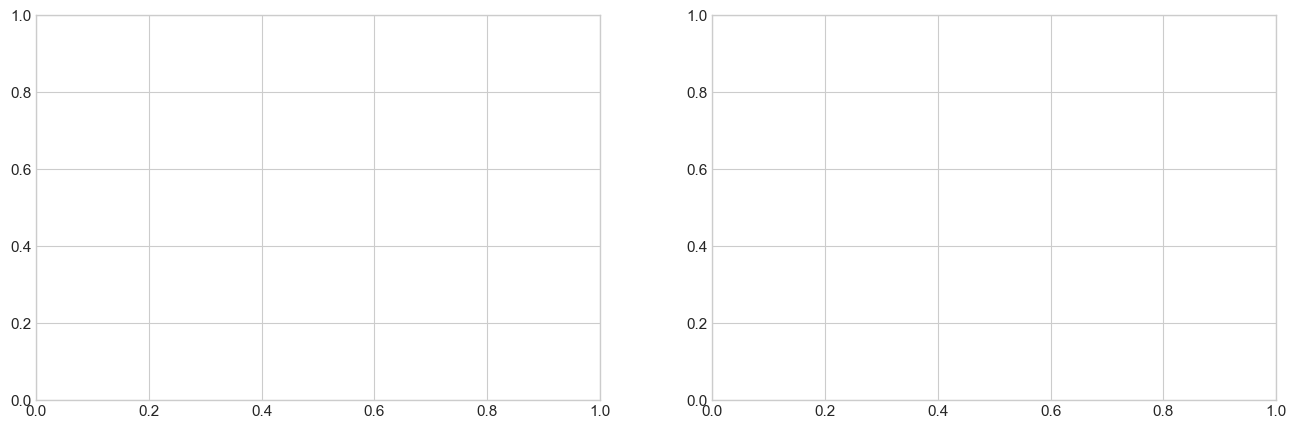

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

## Biểu đồ SalePrice gốc (Nhận xét: Bị lệch phải - Right Skewed)

In [29]:
sns.histplot(train_df['SalePrice'], kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title(f"Phân phối SalePrice Gốc (Skewness: {train_df['SalePrice'].skew():.2f})", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Giá bán SalePrice ($)")

Text(0.5, 4.444444444444448, 'Giá bán SalePrice ($)')

## Biến đổi Log1p đưa SalePrice về Phân phối chuẩn (Normal Distribution)

In [30]:
train_df['SalePrice_Log'] = np.log1p(train_df['SalePrice'])
sns.histplot(train_df['SalePrice_Log'], kde=True, ax=axes[1], color='#059669')
axes[1].set_title(f"Phân phối SalePrice Sau khi Log1p (Skewness: {train_df['SalePrice_Log'].skew():.2f})", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Log1p(SalePrice)")

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

# Phân tích đơn biến cho một số đặc trưng quan trọng

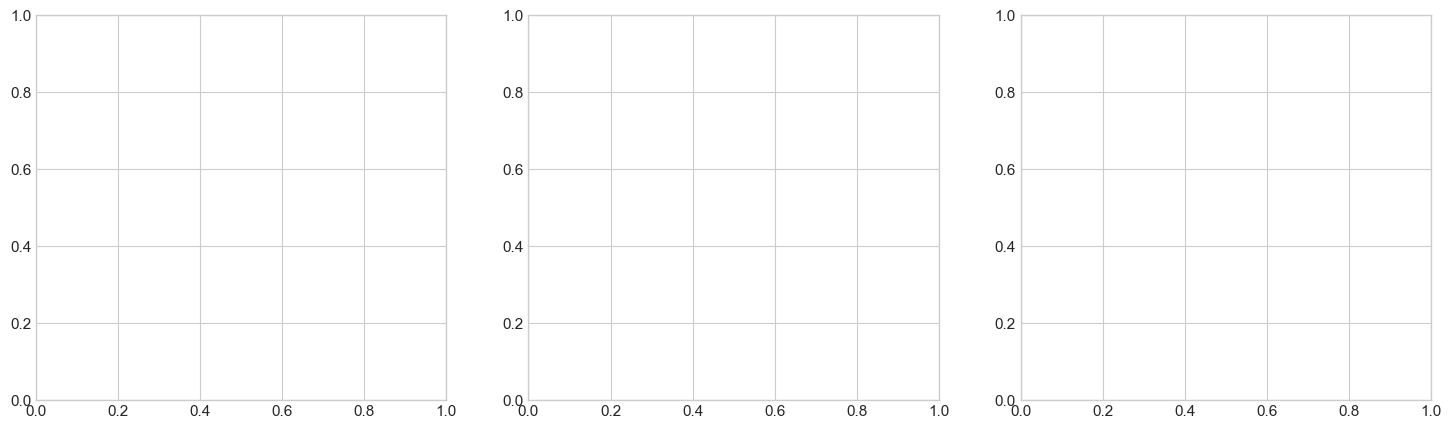

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

## Diện tích sinh hoạt (GrLivArea)

In [ ]:
sns.histplot(train_df['GrLivArea'], kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title('Phân phối diện tích GrLivArea (sq ft)', fontweight='bold')


Text(0.5, 1.0, 'Phân phối diện tích GrLivArea (sq ft)')

## Chất lượng tổng thể (OverallQual)

In [ ]:
sns.countplot(x='OverallQual', data=train_df, ax=axes[1], palette='Blues_r')
axes[1].set_title('Phân phối chất lượng OverallQual (1-10)', fontweight='bold')


Text(0.5, 1.0, 'Phân phối chất lượng OverallQual (1-10)')

## Top 10 Khu vực có nhiều giao dịch nhất (Neighborhood)

In [ ]:
top_neighborhoods = train_df['Neighborhood'].value_counts().head(10)
sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, ax=axes[2], palette='viridis')
axes[2].set_title('Top 10 Khu vực có nhiều giao dịch nhất', fontweight='bold')

plt.tight_layout()
plt.show()



<Figure size 1200x600 with 0 Axes>

# Kiểm tra và Thống kê Dữ liệu bị khuyết (Missing Values)


In [ ]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_perc = (missing / len(train_df)) * 100

missing_df = pd.DataFrame({'Số lượng khuyết': missing, 'Tỉ lệ (%)': missing_perc})

print("\n=== TOP 15 ĐẶC TRƯNG BỊ KHUYẾT DỮ LIỆU NHIỀU NHẤT ===")
print(missing_df.head(15))




=== TOP 15 ĐẶC TRƯNG BỊ KHUYẾT DỮ LIỆU NHIỀU NHẤT ===
              Số lượng khuyết  Tỉ lệ (%)
PoolQC                   1453  99.520548
MiscFeature              1406  96.301370
Alley                    1369  93.767123
Fence                    1179  80.753425
MasVnrType                872  59.726027
FireplaceQu               690  47.260274
LotFrontage               259  17.739726
GarageType                 81   5.547945
GarageYrBlt                81   5.547945
GarageFinish               81   5.547945
GarageQual                 81   5.547945
GarageCond                 81   5.547945
BsmtFinType2               38   2.602740
BsmtExposure               38   2.602740
BsmtFinType1               37   2.534247


## Biểu đồ hiển thị dữ liệu thiếu

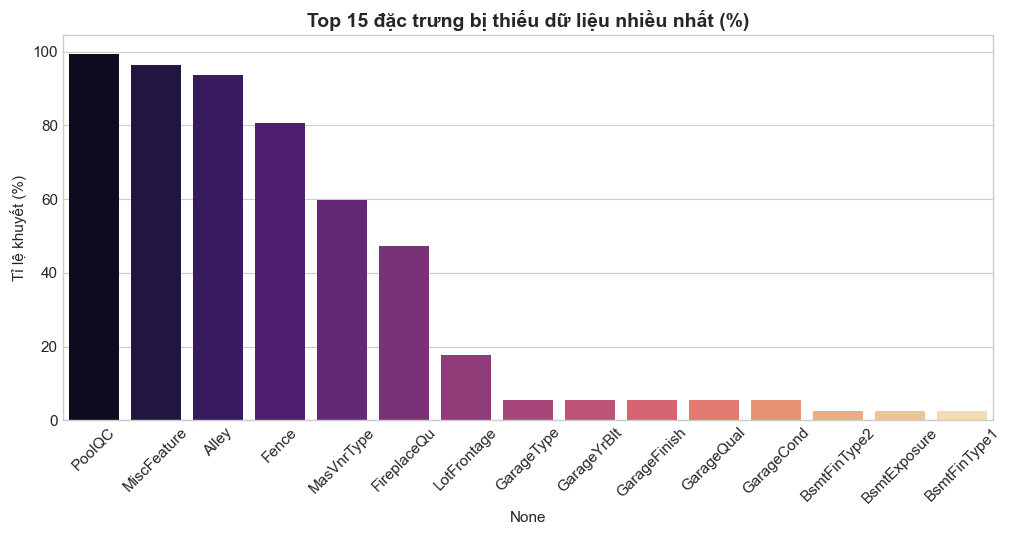

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(x=missing_df.head(15).index, y=missing_df.head(15)['Tỉ lệ (%)'], palette='magma')
plt.xticks(rotation=45)
plt.title('Top 15 đặc trưng bị thiếu dữ liệu nhiều nhất (%)', fontsize=14, fontweight='bold')
plt.ylabel('Tỉ lệ khuyết (%)')
plt.show()

##  Ma trận tương quan (Correlation Heatmap) với SalePrice


In [ ]:
numeric_df = train_df.select_dtypes(include=['int64', 'float64']).drop(columns=['Id'])
corr_matrix = numeric_df.corr()


## Top 10 đặc trưng tương quan cao nhất với SalePrice

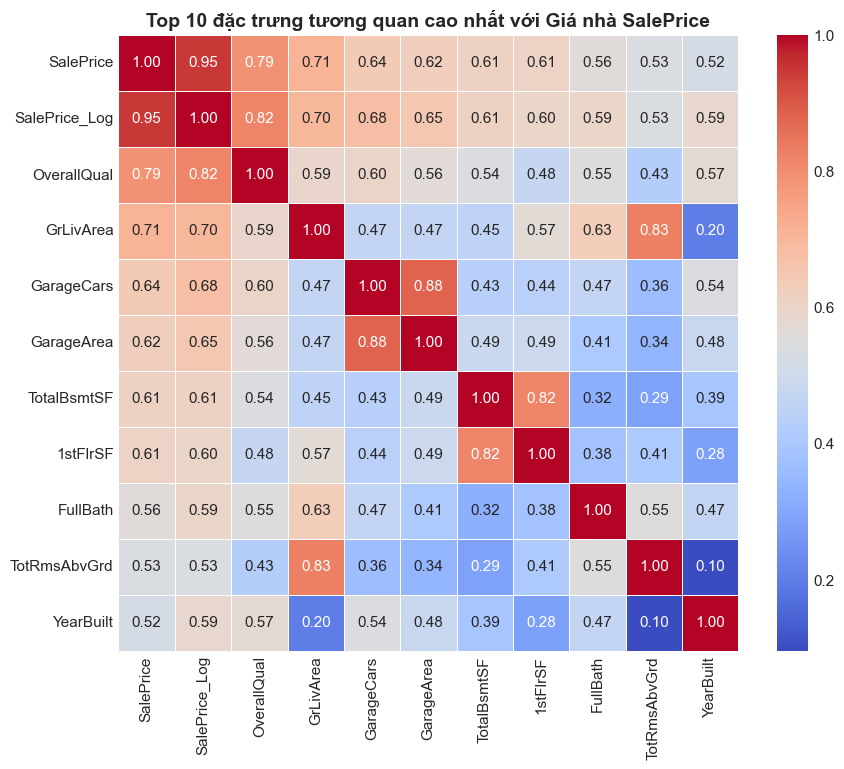

In [ ]:
top_corr_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(11).index

plt.figure(figsize=(10, 8))
sns.heatmap(train_df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Top 10 đặc trưng tương quan cao nhất với Giá nhà SalePrice', fontsize=14, fontweight='bold')
plt.show()


## Biểu đồ mối quan hệ Đa biến (Scatter Plot & Boxplot)

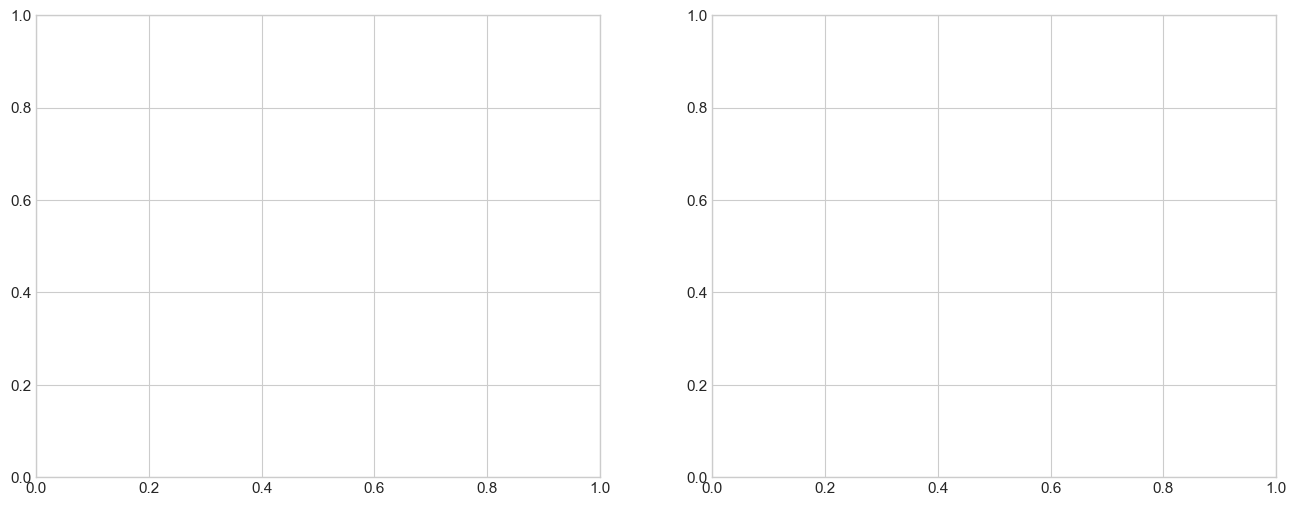

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


## Scatter plot: GrLivArea vs SalePrice

In [31]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_df, ax=axes[0], color='#2563eb', alpha=0.6)
axes[0].set_title('Mối quan hệ giữa Diện tích GrLivArea và SalePrice', fontweight='bold')



Text(0.5, 1.0, 'Mối quan hệ giữa Diện tích GrLivArea và SalePrice')

## Boxplot: OverallQual vs SalePrice

In [32]:
sns.boxplot(x='OverallQual', y='SalePrice', data=train_df, ax=axes[1], palette='Spectral')
axes[1].set_title('Biến động Giá nhà theo Đánh giá Chất lượng OverallQual', fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

## Xác định Ngoại lệ (Outliers) theo khuyến nghị của Paper (Dean De Cock)

### Tìm các căn nhà diện tích GrLivArea > 4000 sq ft nhưng SalePrice < $300,000

In [33]:
outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]

print("\n=== DANH SÁCH MẪU NGOẠI LỆ CỰC ĐOAN (OUTLIERS) PHÁT HIỆN ===")
print(outliers[['Id', 'GrLivArea', 'OverallQual', 'SalePrice']])



=== DANH SÁCH MẪU NGOẠI LỆ CỰC ĐOAN (OUTLIERS) PHÁT HIỆN ===
        Id  GrLivArea  OverallQual  SalePrice
523    524       4676           10     184750
1298  1299       5642           10     160000


### Biểu đồ đánh dấu Outliers

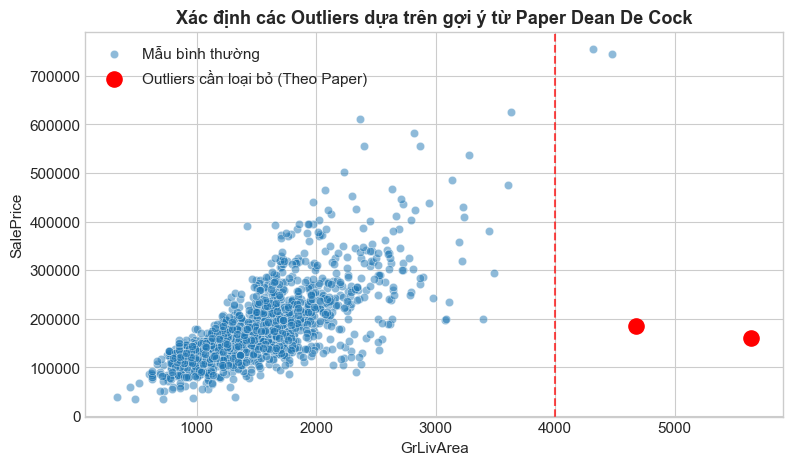

In [34]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train_df, alpha=0.5, label='Mẫu bình thường')
plt.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=120, label='Outliers cần loại bỏ (Theo Paper)')
plt.axvline(x=4000, color='red', linestyle='--', alpha=0.7)
plt.title('Xác định các Outliers dựa trên gợi ý từ Paper Dean De Cock', fontsize=13, fontweight='bold')
plt.legend()
plt.show()
